FULL LIST OF REPEATED SOLUTIONS (19 Total Repeats Found)
 Word  1st Game #   1st Date  2nd Game #   2nd Date  Gap (Games)
cigar           0 2021-06-19        1689 2026-02-02         1689
awake           4 2021-06-23        1708 2026-02-21         1704
grade          15 2021-07-04        1730 2026-03-15         1715
linen          51 2021-08-09        1718 2026-03-03         1667
stand          57 2021-08-15        1765 2026-04-19         1708
ivory          59 2021-08-17        1742 2026-03-27         1683
stout          65 2021-08-23        1850 2026-07-13         1785
flume          68 2021-08-26        1867 2026-07-30         1799
agree          70 2021-08-28        1797 2026-05-21         1727
thumb         115 2021-10-12        1814 2026-06-07         1699
comet         122 2021-10-19        1745 2026-03-30         1623
clock         160 2021-11-26        1788 2026-05-12         1628
bring         164 2021-11-30        1778 2026-05-02         1614
break         172 2021-12-08     

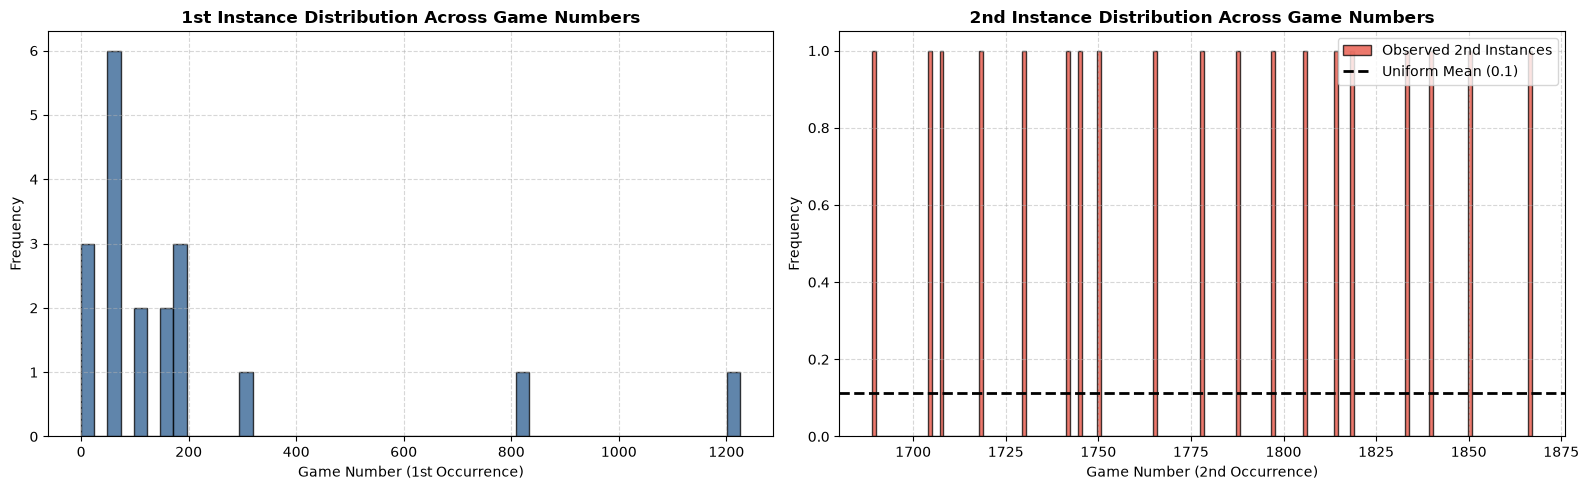

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
df = pd.read_csv('../data/past_answers.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Track occurrence order for each solution word
df['occurrence'] = df.groupby('solution').cumcount() + 1

# Separate 1st and 2nd instances
inst1 = df[df['occurrence'] == 1].set_index('solution')
inst2 = df[df['occurrence'] == 2].set_index('solution')

# Join 1st and 2nd instances (filters for words that have repeated at least once)
repeats = inst1[['game_num', 'date']].join(
    inst2[['game_num', 'date']], 
    lsuffix='_1st', 
    rsuffix='_2nd', 
    how='inner'
).reset_index()

# Calculate gap in games between repeat instances
repeats['game_gap'] = repeats['game_num_2nd'] - repeats['game_num_1st']

# Format date strings for readable display
repeats['date_1st_str'] = repeats['date_1st'].dt.strftime('%Y-%m-%d')
repeats['date_2nd_str'] = repeats['date_2nd'].dt.strftime('%Y-%m-%d')

# 3. Print the full list of repeats
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 80)
print(f"FULL LIST OF REPEATED SOLUTIONS ({len(repeats)} Total Repeats Found)")
print("=" * 80)
print(repeats[['solution', 'game_num_1st', 'date_1st_str', 'game_num_2nd', 'date_2nd_str', 'game_gap']]
      .rename(columns={
          'solution': 'Word',
          'game_num_1st': '1st Game #',
          'date_1st_str': '1st Date',
          'game_num_2nd': '2nd Game #',
          'date_2nd_str': '2nd Date',
          'game_gap': 'Gap (Games)'
      }).to_string(index=False))

# 4. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Graph 1: Distribution of 1st Instances ---
axes[0].hist(repeats['game_num_1st'], bins=50, color='#2b5c8f', edgecolor='black', alpha=0.75)
axes[0].set_title('1st Instance Distribution Across Game Numbers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Game Number (1st Occurrence)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: Distribution of 2nd Instances vs Uniform Expected ---
counts, bins, _ = axes[1].hist(
    repeats['game_num_2nd'], 
    bins=167, 
    color='#e74c3c', 
    edgecolor='black', 
    alpha=0.75, 
    label='Observed 2nd Instances'
)

# Reference line showing theoretical uniform average (expected if purely random/even distribution)
expected_even = len(repeats) / len(bins[:-1])
axes[1].axhline(expected_even, color='black', linestyle='--', linewidth=2, label=f'Uniform Mean ({expected_even:.1f})')

axes[1].set_title('2nd Instance Distribution Across Game Numbers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Game Number (2nd Occurrence)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import scipy.stats as stats

# Sort second instances by game number
gnum_2nd = np.sort(repeats['game_num_2nd'].values)

# Calculate gaps between consecutive repeat events
consecutive_gaps = np.diff(gnum_2nd)

# -------------------------------------------------------------
# TEST 1: EVEN SPACING / DISPERSION TEST (Coefficient of Variation)
# -------------------------------------------------------------
mean_gap = np.mean(consecutive_gaps)
std_gap = np.std(consecutive_gaps, ddof=1)
cv = std_gap / mean_gap

print("=" * 60)
print("1. INTER-ARRIVAL GAP SPACING TEST")
print("=" * 60)
print(f"Mean Gap Between Repeats : {mean_gap:.2f} games")
print(f"Std Dev of Gaps          : {std_gap:.2f} games")
print(f"Coefficient of Var (CV)  : {cv:.3f}")

if cv < 0.8:
    print("--> RESULT: Gaps are MORE EVENLY SPACED than pure random chance (CV < 1.0).")
elif cv > 1.2:
    print("--> RESULT: Repeats are CLUSTERED together (CV > 1.0).")
else:
    print("--> RESULT: Gap spacing is consistent with pure RANDOM CHANCE (CV ≈ 1.0).")

# -------------------------------------------------------------
# TEST 2: KOLMOGOROV-SMIRNOV TEST FOR UNIFORMITY
# -------------------------------------------------------------
# Set the evaluation window from the first repeat to the latest game played
min_g = gnum_2nd.min()
max_g = df['game_num'].max()

# Scale game numbers across the active repeat era
norm_gnum = (gnum_2nd - min_g) / (max_g - min_g)
ks_stat, ks_pvalue = stats.kstest(norm_gnum, 'uniform')

print("\n" + "=" * 60)
print("2. KOLMOGOROV-SMIRNOV UNIFORMITY TEST")
print("=" * 60)
print(f"KS Statistic : {ks_stat:.4f}")
print(f"p-value      : {ks_pvalue:.4f}")

if ks_pvalue < 0.05:
    print("--> RESULT: Reject Null Hypothesis. 2nd instances deviate significantly from uniform randomness.")
else:
    print("--> RESULT: Fail to reject Null Hypothesis. 2nd instances look uniformly random over time.")

# -------------------------------------------------------------
# TEST 3: EXPONENTIAL FIT TEST ON GAPS
# -------------------------------------------------------------
# If arrivals are Poisson, gaps must follow an Exponential distribution
gap_ks_stat, gap_pvalue = stats.kstest(consecutive_gaps, 'expon', args=(0, mean_gap))

print("\n" + "=" * 60)
print("3. EXPONENTIAL DISTRIBUTION GAP TEST")
print("=" * 60)
print(f"KS Statistic : {gap_ks_stat:.4f}")
print(f"p-value      : {gap_pvalue:.4f}")

if gap_pvalue < 0.05:
    print("--> RESULT: Gaps do NOT follow an exponential distribution (non-random spacing).")
else:
    print("--> RESULT: Gaps are consistent with a memoryless random process.")

1. INTER-ARRIVAL GAP SPACING TEST
Mean Gap Between Repeats : 9.89 games
Std Dev of Gaps          : 4.07 games
Coefficient of Var (CV)  : 0.412
--> RESULT: Gaps are MORE EVENLY SPACED than pure random chance (CV < 1.0).

2. KOLMOGOROV-SMIRNOV UNIFORMITY TEST
KS Statistic : 0.0784
p-value      : 0.9991
--> RESULT: Fail to reject Null Hypothesis. 2nd instances look uniformly random over time.

3. EXPONENTIAL DISTRIBUTION GAP TEST
KS Statistic : 0.2858
p-value      : 0.0856
--> RESULT: Gaps are consistent with a memoryless random process.


TEST 1: BUCKET MASS ANALYSIS (Observed vs. Theoretical Probability Share)
    Bracket  Obs # Obs % Uniform % NYT Discrete % Quad Original % Quad Cont. %
    0 - 190     16 84.2%     10.2%          30.8%           42.8%        34.3%
  191 - 480      1  5.3%     15.5%          46.8%           34.9%        28.0%
 481 - 1000      1  5.3%     27.8%           8.4%           16.9%        27.5%
1001 - 1867      1  5.3%     46.4%          14.0%            5.5%        10.2%

TEST 2 & 3: LOG-LIKELIHOOD & KS GOODNESS-OF-FIT RANKINGS
                      Model  Log-Likelihood (L) Delta L (vs Uniform)  KS Statistic (D)  KS p-value Good Fit (p > 0.05)?
             Uniform (Flat)           -143.1198              +0.0000            0.7399      0.0000                   NO
     NYT Discrete (1.0/0.1)           -126.7606             +16.3592            0.5339      0.0000                   NO
  Piecewise Quad (Original)           -121.8366             +21.2833            0.4144      0.0018               

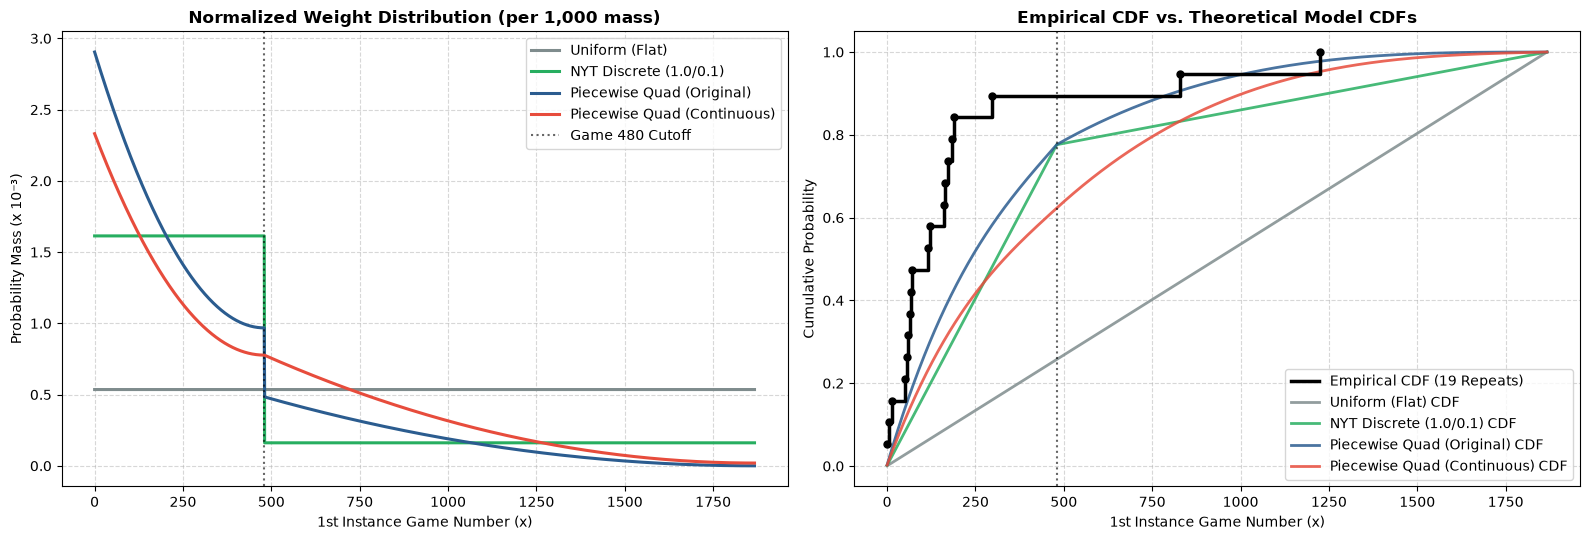

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==============================================================================
# 0. SETUP & MODEL DEFINITIONS
# ==============================================================================
# Define current game horizon p from loaded data
p = int(df['game_num'].max())
x_domain = np.arange(0, p + 1)
observed_origins = np.sort(repeats['game_num_1st'].values)

# Model 1: Uniform (Flat Baseline - Bot 6 & 7)
w_uniform = np.ones_like(x_domain, dtype=float)

# Model 2: NYT Two-Tier Discrete (1.0 for x <= 480, 0.1 for x > 480)
w_nyt_discrete = np.where(x_domain <= 480, 1.0, 0.1)

# Model 3: User's Original Piecewise Quadratic (Cliff at 480: 2.0 -> 1.0)
w_quad_original = np.where(
    x_domain <= 480,
    (4.0 / (480.0 ** 2)) * ((x_domain - 480.0) ** 2) + 2.0,
    (1.0 / ((p - 480.0) ** 2)) * ((x_domain - p) ** 2)
)

# Model 4: Continuous & Floored Quadratic (Seamless 2.0 transition + 0.05 floor)
w_quad_continuous = np.where(
    x_domain <= 480,
    (4.0 / (480.0 ** 2)) * ((x_domain - 480.0) ** 2) + 2.0,
    (1.95 / ((p - 480.0) ** 2)) * ((x_domain - p) ** 2) + 0.05
)

# Normalize all weights into valid Probability Distributions over [0, p]
models = {
    "Uniform (Flat)": w_uniform / np.sum(w_uniform),
    "NYT Discrete (1.0/0.1)": w_nyt_discrete / np.sum(w_nyt_discrete),
    "Piecewise Quad (Original)": w_quad_original / np.sum(w_quad_original),
    "Piecewise Quad (Continuous)": w_quad_continuous / np.sum(w_quad_continuous),
}

# ==============================================================================
# 1. BUCKET MASS TEST
# ==============================================================================
brackets = [(0, 190), (191, 480), (481, 1000), (1001, p)]
bucket_results = []

for low, high in brackets:
    # Empirical count & percentage
    obs_count = np.sum((observed_origins >= low) & (observed_origins <= high))
    obs_pct = (obs_count / len(observed_origins)) * 100.0
    
    # Theoretical mass across each model
    row = {
        "Bracket": f"{low} - {high}",
        "Obs #": obs_count,
        "Obs %": f"{obs_pct:.1f}%",
        "Uniform %": f"{np.sum(models['Uniform (Flat)'][low:high+1])*100:.1f}%",
        "NYT Discrete %": f"{np.sum(models['NYT Discrete (1.0/0.1)'][low:high+1])*100:.1f}%",
        "Quad Original %": f"{np.sum(models['Piecewise Quad (Original)'][low:high+1])*100:.1f}%",
        "Quad Cont. %": f"{np.sum(models['Piecewise Quad (Continuous)'][low:high+1])*100:.1f}%",
    }
    bucket_results.append(row)

print("=" * 105)
print("TEST 1: BUCKET MASS ANALYSIS (Observed vs. Theoretical Probability Share)")
print("=" * 105)
print(pd.DataFrame(bucket_results).to_string(index=False))
print()

# ==============================================================================
# 2. LOG-LIKELIHOOD & 3. KS GOODNESS-OF-FIT TESTS
# ==============================================================================
stats_results = []
baseline_ll = np.sum(np.log(models["Uniform (Flat)"][observed_origins]))

for name, prob_dist in models.items():
    # Log-Likelihood on observed repeat origins
    ll = np.sum(np.log(prob_dist[observed_origins]))
    delta_ll = ll - baseline_ll
    
    # KS-Test against theoretical CDF
    cdf_theoretical = np.cumsum(prob_dist)
    
    # Callable CDF interpolator for scipy.stats.ks_1samp
    def cdf_func(x_vals, cdf_arr=cdf_theoretical, max_idx=p):
        idx = np.clip(np.floor(x_vals).astype(int), 0, max_idx)
        return cdf_arr[idx]
        
    ks_stat, p_val = stats.ks_1samp(observed_origins, cdf_func)
    
    stats_results.append({
        "Model": name,
        "Log-Likelihood (L)": round(ll, 4),
        "Delta L (vs Uniform)": f"{delta_ll:+10.4f}",
        "KS Statistic (D)": round(ks_stat, 4),
        "KS p-value": round(p_val, 4),
        "Good Fit (p > 0.05)?": "YES" if p_val > 0.05 else "NO"
    })

print("=" * 105)
print("TEST 2 & 3: LOG-LIKELIHOOD & KS GOODNESS-OF-FIT RANKINGS")
print("=" * 105)
print(pd.DataFrame(stats_results).to_string(index=False))
print()

# ==============================================================================
# 4. VISUAL DIAGNOSTIC SUITE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Palette for clear differentiation
colors = {
    "Uniform (Flat)": "#7f8c8d",
    "NYT Discrete (1.0/0.1)": "#27ae60",
    "Piecewise Quad (Original)": "#2b5c8f",
    "Piecewise Quad (Continuous)": "#e74c3c"
}

# --- Subplot 1: Normalized Probability Density Curves ---
for name, prob_dist in models.items():
    axes[0].plot(x_domain, prob_dist * 1000, label=name, color=colors[name], linewidth=2.2)

axes[0].set_title("Normalized Weight Distribution (per 1,000 mass)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("1st Instance Game Number (x)")
axes[0].set_ylabel("Probability Mass (x 10⁻³)")
axes[0].axvline(480, color='black', linestyle=':', alpha=0.6, label='Game 480 Cutoff')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Subplot 2: Empirical CDF vs. Theoretical CDFs ---
# Plot Empirical CDF staircase
emp_x = np.sort(observed_origins)
emp_y = np.arange(1, len(emp_x) + 1) / len(emp_x)
axes[1].step(emp_x, emp_y, where='post', color='black', linewidth=2.5, label='Empirical CDF (19 Repeats)', zorder=5)
axes[1].plot(emp_x, emp_y, 'ko', markersize=5, zorder=5)

# Overlay Theoretical CDFs
for name, prob_dist in models.items():
    cdf_theoretical = np.cumsum(prob_dist)
    axes[1].plot(x_domain, cdf_theoretical, label=f"{name} CDF", color=colors[name], linewidth=2.0, alpha=0.85)

axes[1].set_title("Empirical CDF vs. Theoretical Model CDFs", fontsize=12, fontweight='bold')
axes[1].set_xlabel("1st Instance Game Number (x)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].axvline(480, color='black', linestyle=':', alpha=0.6)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

TEST 1 (LOMAX REVISITED): BUCKET MASS ANALYSIS
    Bracket  Obs # Obs % Original (480) % Lomax (c=50) % Lomax (c=75) % Lomax (c=100) %
    0 - 190     16 84.2%            42.8%          81.5%          74.8%           69.3%
  191 - 480      1  5.3%            34.9%          11.5%          15.2%           18.0%
 481 - 1000      1  5.3%            16.9%           4.7%           6.7%            8.5%
1001 - 1867      1  5.3%             5.5%           2.2%           3.2%            4.2%

TEST 2 & 3 (LOMAX REVISITED): STATISTICAL GOODNESS-OF-FIT RANKINGS
                     Model  Log-Likelihood (L) Delta L (vs Uniform)  KS Statistic (D)  KS p-value Good Fit (p > 0.05)?
            Uniform (Flat)           -143.1198              +0.0000            0.7399      0.0000                   NO
Quad Original (480 Cutoff)           -121.8366             +21.2833            0.4144      0.0018                   NO
            Lomax (c = 50)           -120.2380             +22.8819            0.3680   

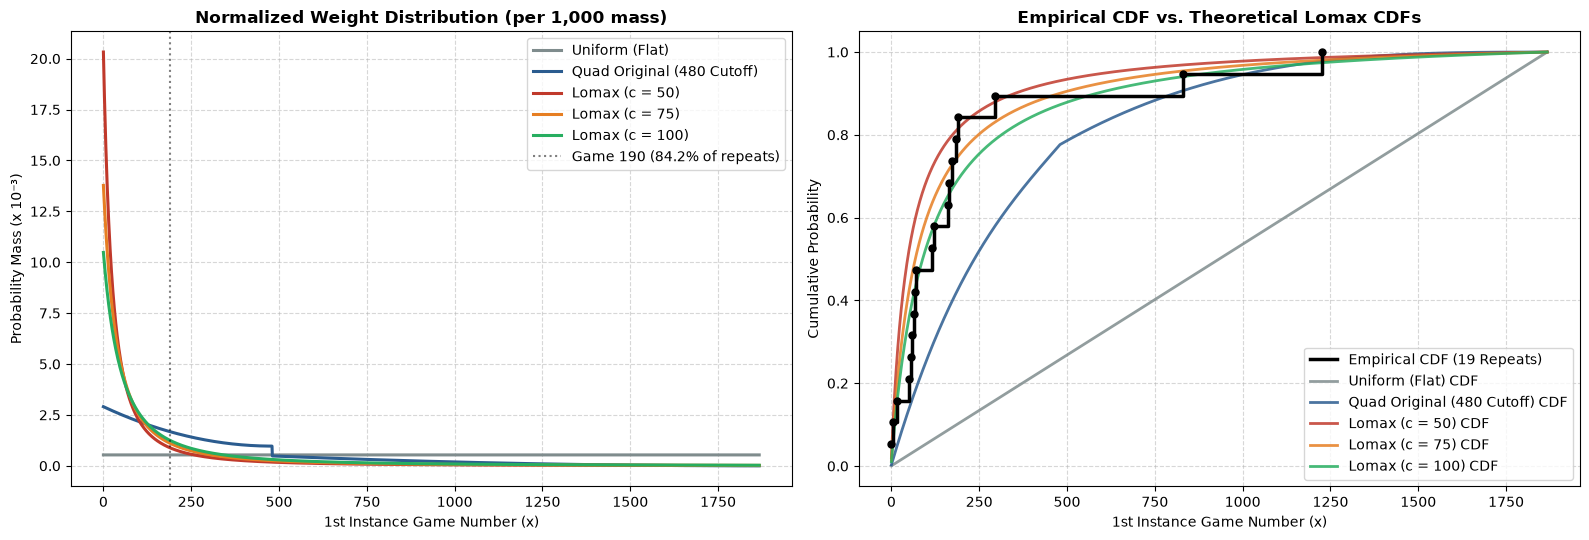

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# ==============================================================================
# 5. NEW MODEL DEFINITIONS: LOMAX (PARETO TYPE II) AGE CURVES
# ==============================================================================
# Lomax weight formula: w(x) = 1 / (x + c)^2
w_lomax_50  = 1.0 / ((x_domain + 50.0)  ** 2)
w_lomax_75  = 1.0 / ((x_domain + 75.0)  ** 2)
w_lomax_100 = 1.0 / ((x_domain + 100.0) ** 2)

# Build the comparison suite
lomax_models = {
    "Uniform (Flat)": w_uniform / np.sum(w_uniform),
    "Quad Original (480 Cutoff)": w_quad_original / np.sum(w_quad_original),
    "Lomax (c = 50)":  w_lomax_50  / np.sum(w_lomax_50),
    "Lomax (c = 75)":  w_lomax_75  / np.sum(w_lomax_75),
    "Lomax (c = 100)": w_lomax_100 / np.sum(w_lomax_100),
}

# ==============================================================================
# 6. BUCKET MASS ANALYSIS FOR LOMAX MODELS
# ==============================================================================
lomax_bucket_results = []

for low, high in brackets:
    obs_count = np.sum((observed_origins >= low) & (observed_origins <= high))
    obs_pct = (obs_count / len(observed_origins)) * 100.0
    
    row = {
        "Bracket": f"{low} - {high}",
        "Obs #": obs_count,
        "Obs %": f"{obs_pct:.1f}%",
        "Original (480) %": f"{np.sum(lomax_models['Quad Original (480 Cutoff)'][low:high+1])*100:.1f}%",
        "Lomax (c=50) %":   f"{np.sum(lomax_models['Lomax (c = 50)'][low:high+1])*100:.1f}%",
        "Lomax (c=75) %":   f"{np.sum(lomax_models['Lomax (c = 75)'][low:high+1])*100:.1f}%",
        "Lomax (c=100) %":  f"{np.sum(lomax_models['Lomax (c = 100)'][low:high+1])*100:.1f}%",
    }
    lomax_bucket_results.append(row)

print("=" * 100)
print("TEST 1 (LOMAX REVISITED): BUCKET MASS ANALYSIS")
print("=" * 100)
print(pd.DataFrame(lomax_bucket_results).to_string(index=False))
print()

# ==============================================================================
# 7. LOG-LIKELIHOOD & KS GOODNESS-OF-FIT FOR LOMAX MODELS
# ==============================================================================
lomax_stats_results = []

for name, prob_dist in lomax_models.items():
    ll = np.sum(np.log(prob_dist[observed_origins]))
    delta_ll = ll - baseline_ll
    
    cdf_theoretical = np.cumsum(prob_dist)
    
    # Isolate interpolator scope per loop iteration
    def make_cdf_func(cdf_arr):
        def cdf_func(x_vals):
            idx = np.clip(np.floor(x_vals).astype(int), 0, p)
            return cdf_arr[idx]
        return cdf_func
        
    ks_stat, p_val = stats.ks_1samp(observed_origins, make_cdf_func(cdf_theoretical))
    
    lomax_stats_results.append({
        "Model": name,
        "Log-Likelihood (L)": round(ll, 4),
        "Delta L (vs Uniform)": f"{delta_ll:+10.4f}",
        "KS Statistic (D)": round(ks_stat, 4),
        "KS p-value": round(p_val, 4),
        "Good Fit (p > 0.05)?": "YES" if p_val > 0.05 else "NO"
    })

print("=" * 100)
print("TEST 2 & 3 (LOMAX REVISITED): STATISTICAL GOODNESS-OF-FIT RANKINGS")
print("=" * 100)
print(pd.DataFrame(lomax_stats_results).to_string(index=False))
print()

# ==============================================================================
# 8. VISUAL DIAGNOSTIC SUITE FOR LOMAX MODELS
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

lomax_colors = {
    "Uniform (Flat)": "#7f8c8d",
    "Quad Original (480 Cutoff)": "#2b5c8f",
    "Lomax (c = 50)":  "#c0392b",
    "Lomax (c = 75)":  "#e67e22",
    "Lomax (c = 100)": "#27ae60",
}

# --- Subplot 1: Normalized Probability Density Curves ---
for name, prob_dist in lomax_models.items():
    axes[0].plot(x_domain, prob_dist * 1000, label=name, color=lomax_colors[name], linewidth=2.2)

axes[0].set_title("Normalized Weight Distribution (per 1,000 mass)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("1st Instance Game Number (x)")
axes[0].set_ylabel("Probability Mass (x 10⁻³)")
axes[0].axvline(190, color='black', linestyle=':', alpha=0.5, label='Game 190 (84.2% of repeats)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Subplot 2: Empirical CDF vs. Theoretical CDFs ---
emp_x = np.sort(observed_origins)
emp_y = np.arange(1, len(emp_x) + 1) / len(emp_x)
axes[1].step(emp_x, emp_y, where='post', color='black', linewidth=2.5, label='Empirical CDF (19 Repeats)', zorder=5)
axes[1].plot(emp_x, emp_y, 'ko', markersize=5, zorder=5)

for name, prob_dist in lomax_models.items():
    cdf_theoretical = np.cumsum(prob_dist)
    axes[1].plot(x_domain, cdf_theoretical, label=f"{name} CDF", color=lomax_colors[name], linewidth=2.0, alpha=0.85)

axes[1].set_title("Empirical CDF vs. Theoretical Lomax CDFs", fontsize=12, fontweight='bold')
axes[1].set_xlabel("1st Instance Game Number (x)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

TEST 1: BUCKET MASS ANALYSIS (Lorentzian Plateau vs. Lomax Spike)
    Bracket  Obs # Obs % Original (480) % Lomax (c=75) % Lorentzian (c=100) %
    0 - 190     16 84.2%            42.8%          74.8%                71.8%
  191 - 480      1  5.3%            34.9%          15.2%                18.3%
 481 - 1000      1  5.3%            16.9%           6.7%                 6.9%
1001 - 1867      1  5.3%             5.5%           3.2%                 3.0%

TEST 2 & 3: STATISTICAL GOODNESS-OF-FIT RANKINGS
                     Model  Log-Likelihood (L) Delta L (vs Uniform)  KS Statistic (D)  KS p-value Good Fit (p > 0.05)?
            Uniform (Flat)           -143.1198              +0.0000            0.7399      0.0000                   NO
Quad Original (480 Cutoff)           -121.8366             +21.2833            0.4144      0.0018                   NO
            Lomax (c = 75)           -118.7280             +24.3918            0.2696      0.1040                  YES
      Lorentzian (

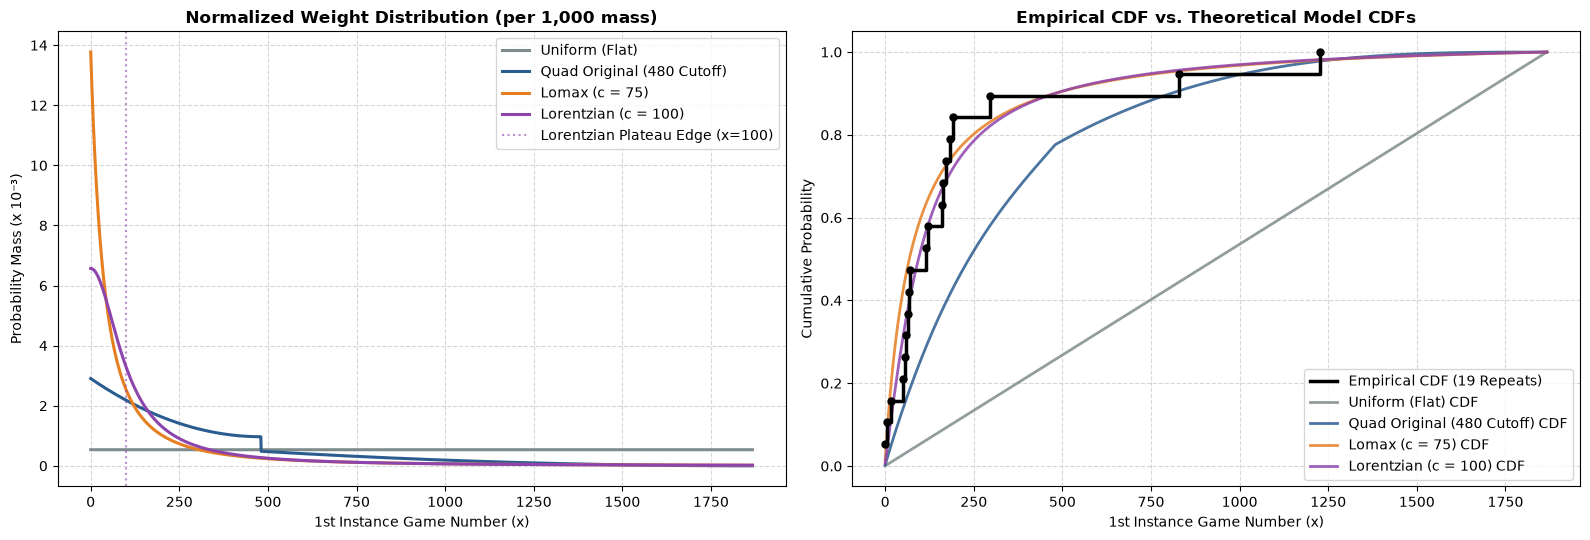

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# ==============================================================================
# 1. MODEL DEFINITIONS: ADDING THE LORENTZIAN (CAUCHY) KERNEL
# ==============================================================================
# Lorentzian weight formula: w(x) = 1 / (x^2 + c^2)
c_lorentz = 100.0
w_lorentzian = 1.0 / ((x_domain ** 2) + (c_lorentz ** 2))

# Build the comparison suite
lorentz_models = {
    "Uniform (Flat)": w_uniform / np.sum(w_uniform),
    "Quad Original (480 Cutoff)": w_quad_original / np.sum(w_quad_original),
    "Lomax (c = 75)": w_lomax_75 / np.sum(w_lomax_75),
    "Lorentzian (c = 100)": w_lorentzian / np.sum(w_lorentzian),
}

# ==============================================================================
# 2. BUCKET MASS ANALYSIS
# ==============================================================================
lorentz_bucket_results = []

for low, high in brackets:
    obs_count = np.sum((observed_origins >= low) & (observed_origins <= high))
    obs_pct = (obs_count / len(observed_origins)) * 100.0
    
    row = {
        "Bracket": f"{low} - {high}",
        "Obs #": obs_count,
        "Obs %": f"{obs_pct:.1f}%",
        "Original (480) %": f"{np.sum(lorentz_models['Quad Original (480 Cutoff)'][low:high+1])*100:.1f}%",
        "Lomax (c=75) %": f"{np.sum(lorentz_models['Lomax (c = 75)'][low:high+1])*100:.1f}%",
        "Lorentzian (c=100) %": f"{np.sum(lorentz_models['Lorentzian (c = 100)'][low:high+1])*100:.1f}%",
    }
    lorentz_bucket_results.append(row)

print("=" * 95)
print("TEST 1: BUCKET MASS ANALYSIS (Lorentzian Plateau vs. Lomax Spike)")
print("=" * 95)
print(pd.DataFrame(lorentz_bucket_results).to_string(index=False))
print()

# ==============================================================================
# 3. LOG-LIKELIHOOD & KS GOODNESS-OF-FIT
# ==============================================================================
lorentz_stats_results = []

for name, prob_dist in lorentz_models.items():
    ll = np.sum(np.log(prob_dist[observed_origins]))
    delta_ll = ll - baseline_ll
    
    cdf_theoretical = np.cumsum(prob_dist)
    
    # Isolate interpolator scope per loop iteration
    def make_cdf_func(cdf_arr):
        def cdf_func(x_vals):
            idx = np.clip(np.floor(x_vals).astype(int), 0, p)
            return cdf_arr[idx]
        return cdf_func
        
    ks_stat, p_val = stats.ks_1samp(observed_origins, make_cdf_func(cdf_theoretical))
    
    lorentz_stats_results.append({
        "Model": name,
        "Log-Likelihood (L)": round(ll, 4),
        "Delta L (vs Uniform)": f"{delta_ll:+10.4f}",
        "KS Statistic (D)": round(ks_stat, 4),
        "KS p-value": round(p_val, 4),
        "Good Fit (p > 0.05)?": "YES" if p_val > 0.05 else "NO"
    })

print("=" * 95)
print("TEST 2 & 3: STATISTICAL GOODNESS-OF-FIT RANKINGS")
print("=" * 95)
print(pd.DataFrame(lorentz_stats_results).to_string(index=False))
print()

# ==============================================================================
# 4. VISUAL DIAGNOSTIC SUITE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

lorentz_colors = {
    "Uniform (Flat)": "#7f8c8d",
    "Quad Original (480 Cutoff)": "#2b5c8f",
    "Lomax (c = 75)": "#e67e22",
    "Lorentzian (c = 100)": "#8e44ad",
}

# --- Subplot 1: Normalized Probability Density Curves ---
for name, prob_dist in lorentz_models.items():
    axes[0].plot(x_domain, prob_dist * 1000, label=name, color=lorentz_colors[name], linewidth=2.2)

axes[0].set_title("Normalized Weight Distribution (per 1,000 mass)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("1st Instance Game Number (x)")
axes[0].set_ylabel("Probability Mass (x 10⁻³)")
axes[0].axvline(100, color='#8e44ad', linestyle=':', alpha=0.6, label='Lorentzian Plateau Edge (x=100)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Subplot 2: Empirical CDF vs. Theoretical CDFs ---
emp_x = np.sort(observed_origins)
emp_y = np.arange(1, len(emp_x) + 1) / len(emp_x)
axes[1].step(emp_x, emp_y, where='post', color='black', linewidth=2.5, label='Empirical CDF (19 Repeats)', zorder=5)
axes[1].plot(emp_x, emp_y, 'ko', markersize=5, zorder=5)

for name, prob_dist in lorentz_models.items():
    cdf_theoretical = np.cumsum(prob_dist)
    axes[1].plot(x_domain, cdf_theoretical, label=f"{name} CDF", color=lorentz_colors[name], linewidth=2.0, alpha=0.85)

axes[1].set_title("Empirical CDF vs. Theoretical Model CDFs", fontsize=12, fontweight='bold')
axes[1].set_xlabel("1st Instance Game Number (x)")
axes[1].set_ylabel("Cumulative Probability")
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()